# MLP: classificazione di feature reali e sintetiche

## Abstract

Questo notebook addestra e valuta un Multi-Layer Perceptron (MLP) per distinguere feature **real** (label 0) e **fake** (label 1). Usa le cache tabulari persistenti generate dal notebook di esplorazione: `mean_std` (2560 feature, esperimento primario) e, se attivata in configurazione, `GAP` (1280 feature, ablation). Lo `StandardScaler` viene appreso esclusivamente dal training; PyTorch implementa una rete Linear–LayerNorm–GELU–Dropout, AdamW, scheduler e early stopping basato soltanto sulla balanced accuracy di validation. Il notebook salva modello, scaler, TorchScript, metriche, predizioni, curve e metadati in una directory di run riproducibile. Rileva automaticamente ambiente locale/Google Colab, monta e usa Drive solo su Colab, e seleziona CUDA quando realmente disponibile con fallback CPU.

## 1. Setup portabile dei percorsi

La cella seguente rileva l'ambiente, monta Google Drive soltanto in Colab, verifica e mette in cache i due file originali nella VM Colab, quindi espone percorsi comuni per dati e output persistenti.

In [1]:
from pathlib import Path
import importlib.util
import shutil

try:
    IS_COLAB = importlib.util.find_spec('google.colab') is not None
except ModuleNotFoundError:
    IS_COLAB = False
EXPECTED_FILES = {'features_0.npy': 2_167_931_008, 'features_1.npy': 3_123_445_888}

if IS_COLAB:
    from google.colab import drive

    DRIVE_MOUNT = Path('/content/drive')
    if not (DRIVE_MOUNT / 'MyDrive').exists():
        drive.mount(str(DRIVE_MOUNT), force_remount=False)

    PROJECT_ROOT = DRIVE_MOUNT / 'MyDrive' / 'Magistrale' / 'Advanced_ML' / 'progetto_aml'
    PERSISTENT_DATASET_DIR = PROJECT_ROOT / 'dataset'
    if not PERSISTENT_DATASET_DIR.is_dir():
        raise FileNotFoundError(f'Dataset directory non trovata su Drive: {PERSISTENT_DATASET_DIR}')

    RUNTIME_PROJECT_ROOT = Path('/content/progetto_aml')
    RUNTIME_DATASET_DIR = RUNTIME_PROJECT_ROOT / 'dataset'
    RUNTIME_DATASET_DIR.mkdir(parents=True, exist_ok=True)
    for filename, expected_size in EXPECTED_FILES.items():
        source = PERSISTENT_DATASET_DIR / filename
        destination = RUNTIME_DATASET_DIR / filename
        if not source.is_file():
            raise FileNotFoundError(f'File originale mancante: {source}')
        if source.stat().st_size != expected_size:
            raise RuntimeError(f'Dimensione inattesa per {source}: {source.stat().st_size}; attesi {expected_size}')
        if not destination.exists() or destination.stat().st_size != expected_size:
            print(f'Copio {filename} da Drive nella VM Colab...')
            shutil.copy2(source, destination)
        if destination.stat().st_size != expected_size:
            raise RuntimeError(f'Copia incompleta: {destination}')

    DATASET_DIR = RUNTIME_DATASET_DIR
    PROCESSED_DATASET_DIR = PERSISTENT_DATASET_DIR
    ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
    RESULTS_DIR = PROJECT_ROOT / 'results'
else:
    PROJECT_ROOT = Path.cwd()
    if not (PROJECT_ROOT / 'dataset').is_dir():
        PROJECT_ROOT = PROJECT_ROOT.parent
    PERSISTENT_DATASET_DIR = PROJECT_ROOT / 'dataset'
    DATASET_DIR = PERSISTENT_DATASET_DIR
    PROCESSED_DATASET_DIR = PERSISTENT_DATASET_DIR
    ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
    RESULTS_DIR = PROJECT_ROOT / 'results'

if not PERSISTENT_DATASET_DIR.is_dir():
    raise FileNotFoundError(f'Dataset directory non trovata: {PERSISTENT_DATASET_DIR}')
for directory in (PROCESSED_DATASET_DIR, ARTIFACTS_DIR, RESULTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print('Ambiente:', 'Google Colab' if IS_COLAB else 'Locale')
print('Dataset per lettura:', DATASET_DIR)
print('Dataset persistente:', PROCESSED_DATASET_DIR)
print('Artifacts:', ARTIFACTS_DIR)
print('Results:', RESULTS_DIR)

Ambiente: Locale
Dataset per lettura: c:\Users\leona\venv_aml\dataset
Dataset persistente: c:\Users\leona\venv_aml\dataset
Artifacts: c:\Users\leona\venv_aml\artifacts
Results: c:\Users\leona\venv_aml\results


## 2. Dipendenze, semi e configurazione sperimentale

La cella installa solo dipendenze assenti, registra le versioni, imposta i semi e la determinismo di PyTorch, sceglie il device e definisce una configurazione modificabile. L'ablation GAP è disattivata per default per privilegiare l'esperimento primario `mean_std`.

In [2]:
import subprocess
import sys

REQUIRED_PACKAGES = {'numpy': 'numpy', 'pandas': 'pandas', 'matplotlib': 'matplotlib', 'sklearn': 'scikit-learn', 'joblib': 'joblib', 'torch': 'torch'}
missing_packages = [package for module, package in REQUIRED_PACKAGES.items() if importlib.util.find_spec(module) is None]
if missing_packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', *missing_packages])

import hashlib
import json
import os
import platform
import random
import time
from copy import deepcopy
from datetime import datetime, timezone

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
from IPython.display import display
from sklearn.calibration import calibration_curve
from sklearn.metrics import (accuracy_score, average_precision_score, balanced_accuracy_score, brier_score_loss, confusion_matrix, f1_score, log_loss, precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
MODEL_NAME = 'mlp'
PRIMARY_REPRESENTATION = 'mean_std'
RUN_GAP_ABLATION = False
REPRESENTATIONS_TO_RUN = ('mean_std', 'gap') if RUN_GAP_ABLATION else (PRIMARY_REPRESENTATION,)
HIDDEN_DIMENSIONS = (512, 128)
DROPOUT = 0.30
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
BATCH_SIZE = 128
MAX_EPOCHS = 100
EARLY_STOPPING_PATIENCE = 12
NUM_WORKERS = 0
GRADIENT_CLIP_NORM = 1.0
DECISION_THRESHOLD = 0.50

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
try:
    torch.use_deterministic_algorithms(True, warn_only=True)
except RuntimeError as error:
    print(f'Avviso determinismo PyTorch: {error}')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
AMP_ENABLED = DEVICE.type == 'cuda'
BASE_RUN_ID = f'seed{SEED}_{datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")}'
VERSIONS = {
    'python': platform.python_version(),
    'numpy': np.__version__,
    'pandas': pd.__version__,
    'scikit_learn': sklearn.__version__,
    'pytorch': torch.__version__,
    'cuda': torch.version.cuda if torch.cuda.is_available() else None,
    'device': str(DEVICE),
}
print(json.dumps(VERSIONS, indent=2))
print('Rappresentazioni:', REPRESENTATIONS_TO_RUN)

{
  "python": "3.12.10",
  "numpy": "2.5.2",
  "pandas": "3.0.5",
  "scikit_learn": "1.9.1",
  "pytorch": "2.14.0+cu126",
  "cuda": "12.6",
  "device": "cuda"
}
Rappresentazioni: ('mean_std',)


## 3. Convenzioni di classe, split condiviso e utility di salvataggio

La cella fissa esplicitamente il mapping delle classi, carica o crea in modo idempotente lo split stratificato comune e ne valida esaustività, disgiunzione e hash. Definisce inoltre scritture atomiche e il salvataggio portabile dei checkpoint.

In [3]:
CLASS_MAPPING = {'features_0.npy': {'label': 0, 'name': 'real'}, 'features_1.npy': {'label': 1, 'name': 'fake'}}
POSITIVE_LABEL = 1
POSITIVE_CLASS = 'fake'
N_REAL, N_FAKE, N_TOTAL = 1654, 2383, 4037
labels = np.concatenate((np.zeros(N_REAL, dtype=np.int8), np.ones(N_FAKE, dtype=np.int8)))
assert CLASS_MAPPING['features_1.npy'] == {'label': POSITIVE_LABEL, 'name': POSITIVE_CLASS}

def atomic_json(payload, path):
    temporary_path = path.with_name(path.name + '.tmp')
    with temporary_path.open('w', encoding='utf-8') as handle:
        json.dump(payload, handle, indent=2, ensure_ascii=False, default=str)
    os.replace(temporary_path, path)

def atomic_csv(frame, path):
    temporary_path = path.with_name(path.name + '.tmp')
    frame.to_csv(temporary_path, index=False)
    os.replace(temporary_path, path)

def save_split(path, train_values, validation_values, test_values):
    temporary_path = path.with_name(path.name + '.tmp')
    with temporary_path.open('wb') as handle:
        np.savez_compressed(handle, train_indices=train_values, validation_indices=validation_values, test_indices=test_values)
    os.replace(temporary_path, path)

def stable_split_hash(train_values, validation_values, test_values):
    digest = hashlib.sha256()
    for name, values in (('train', train_values), ('validation', validation_values), ('test', test_values)):
        digest.update(name.encode('utf-8'))
        digest.update(np.asarray(values, dtype='<i8').tobytes())
    return digest.hexdigest()

def validate_splits(train_values, validation_values, test_values):
    parts = [np.asarray(values, dtype=np.int64) for values in (train_values, validation_values, test_values)]
    merged = np.concatenate(parts)
    if len(np.unique(merged)) != N_TOTAL or not np.array_equal(np.sort(merged), np.arange(N_TOTAL)):
        raise RuntimeError('Split non disgiunti oppure non esaustivi')
    if any(values.size == 0 or values.min() < 0 or values.max() >= N_TOTAL for values in parts):
        raise RuntimeError('Indice di split fuori range oppure split vuoto')
    return {name: {'n_samples': int(len(values)), 'real': int((labels[values] == 0).sum()), 'fake': int((labels[values] == 1).sum())} for name, values in zip(('train', 'validation', 'test'), parts)}

def save_torch_checkpoint(checkpoint, filename, run_dir):
    final_path = run_dir / filename
    if IS_COLAB:
        temporary_path = Path('/content') / f'{BASE_RUN_ID}_{filename}'
        torch.save(checkpoint, temporary_path)
        shutil.copy2(temporary_path, final_path)
        temporary_path.unlink()
    else:
        torch.save(checkpoint, final_path)
    if not final_path.is_file():
        raise RuntimeError(f'Checkpoint non salvato correttamente: {final_path}')
    return final_path

SPLIT_PATH = ARTIFACTS_DIR / 'splits_seed42.npz'
if SPLIT_PATH.exists():
    with np.load(SPLIT_PATH, allow_pickle=False) as split_archive:
        train_indices = split_archive['train_indices'].astype(np.int64, copy=False)
        validation_indices = split_archive['validation_indices'].astype(np.int64, copy=False)
        test_indices = split_archive['test_indices'].astype(np.int64, copy=False)
    split_origin = 'loaded'
else:
    all_indices = np.arange(N_TOTAL, dtype=np.int64)
    train_indices, holdout_indices = train_test_split(all_indices, test_size=0.30, stratify=labels, random_state=SEED)
    validation_indices, test_indices = train_test_split(holdout_indices, test_size=0.50, stratify=labels[holdout_indices], random_state=SEED)
    train_indices, validation_indices, test_indices = map(np.sort, (train_indices, validation_indices, test_indices))
    save_split(SPLIT_PATH, train_indices, validation_indices, test_indices)
    split_origin = 'created'

SPLIT_SUMMARY = validate_splits(train_indices, validation_indices, test_indices)
SPLIT_HASH = stable_split_hash(train_indices, validation_indices, test_indices)
print('Split:', split_origin, SPLIT_HASH)
print(json.dumps(SPLIT_SUMMARY, indent=2))

Split: loaded e23bd01e9ec079e665ed5cb58cdba6c190d40bb702919412e2f5f5aeca63cbd6
{
  "train": {
    "n_samples": 2825,
    "real": 1157,
    "fake": 1668
  },
  "validation": {
    "n_samples": 606,
    "real": 248,
    "fake": 358
  },
  "test": {
    "n_samples": 606,
    "real": 249,
    "fake": 357
  }
}


## 4. Caricamento e validazione delle cache tabulari

La cella apre le cache GAP e mean+std in memory mapping, verifica forme, tipi, valori finiti e l'allineamento di `sample_index.csv` con label e split condivisi. Non carica né modifica i tensor spaziali originali.

In [4]:
GAP_PATH = PROCESSED_DATASET_DIR / 'tabular_features_gap.npy'
MEAN_STD_PATH = PROCESSED_DATASET_DIR / 'tabular_features_mean_std.npy'
SAMPLE_INDEX_PATH = PROCESSED_DATASET_DIR / 'sample_index.csv'
for required_path in (GAP_PATH, MEAN_STD_PATH, SAMPLE_INDEX_PATH):
    if not required_path.is_file():
        raise FileNotFoundError(f'Artefatto di preprocessing mancante: {required_path}. Eseguire prima dataset_exploration.ipynb.')

gap_features = np.load(GAP_PATH, mmap_mode='r', allow_pickle=False)
mean_std_features = np.load(MEAN_STD_PATH, mmap_mode='r', allow_pickle=False)
sample_index = pd.read_csv(SAMPLE_INDEX_PATH)
required_columns = ['sample_id', 'source_file', 'source_index', 'label', 'split']
if sample_index.columns.tolist() != required_columns:
    raise RuntimeError(f'Colonne sample_index inattese: {sample_index.columns.tolist()}')
if gap_features.shape != (N_TOTAL, 1280) or mean_std_features.shape != (N_TOTAL, 2560):
    raise RuntimeError(f'Forme cache inattese: GAP={gap_features.shape}, mean_std={mean_std_features.shape}')
if gap_features.dtype != np.float32 or mean_std_features.dtype != np.float32:
    raise RuntimeError('Le cache devono essere float32')
if len(sample_index) != N_TOTAL or not np.array_equal(sample_index['label'].to_numpy(dtype=np.int8), labels):
    raise RuntimeError('sample_index non è allineato alle label attese')
expected_splits = np.full(N_TOTAL, 'unassigned', dtype=object)
expected_splits[train_indices] = 'train'
expected_splits[validation_indices] = 'validation'
expected_splits[test_indices] = 'test'
if not np.array_equal(sample_index['split'].to_numpy(), expected_splits):
    raise RuntimeError('sample_index non è allineato allo split condiviso')
for name, features in (('GAP', gap_features), ('mean+std', mean_std_features)):
    if not np.isfinite(features).all():
        raise ValueError(f'Valori NaN o Inf trovati nella cache {name}')

FEATURE_SETS = {'mean_std': mean_std_features, 'gap': gap_features}
print('GAP:', gap_features.shape, gap_features.dtype)
print('mean+std:', mean_std_features.shape, mean_std_features.dtype)
print('sample_index:', len(sample_index), 'righe')

GAP: (4037, 1280) float32
mean+std: (4037, 2560) float32
sample_index: 4037 righe


## 5. Architettura MLP e funzioni di valutazione

La cella definisce l'architettura parametrica  input → 512 → 128 → 1 con LayerNorm, GELU e Dropout, oltre a funzioni comuni per passaggi di inferenza, selezione della soglia e metriche con `fake` come classe positiva.

### Schema della pipeline MLP

```text
Cache tabulare persistente
  ├─ mean_std: 2560 feature per campione (esperimento primario)
  └─ GAP: 1280 feature per campione (ablation opzionale)
          │
          ▼
Split condiviso e stratificato (seed 42)
  training 70%  → fit dello StandardScaler
  validation 15% → early stopping e selezione della soglia
  test 15%       → sola valutazione finale
          │
          ▼
Feature standardizzate (float32) → DataLoader
          │
          ▼
Linear(input_dim, 512) → LayerNorm → GELU → Dropout(0.30)
          │
          ▼
Linear(512, 128) → LayerNorm → GELU → Dropout(0.30)
          │
          ▼
Linear(128, 1) → logit → sigmoid → probabilità fake
```

La **GELU** (*Gaussian Error Linear Unit*) è una funzione di attivazione non lineare. In forma compatta, `GELU(x) = x · Φ(x)`, dove `Φ(x)` è la funzione di ripartizione della normale standard: invece di azzerare bruscamente tutti i valori negativi come ReLU, modula in modo continuo il passaggio di ciascuna attivazione. Nei layer nascosti dell'MLP introduce quindi non linearità mantenendo transizioni lisce.

L'ottimizzazione usa `BCEWithLogitsLoss`, AdamW, `ReduceLROnPlateau`, clipping dei gradienti e AMP solo quando CUDA è disponibile. Il checkpoint migliore è quello con la maggiore balanced accuracy di validation; soglia e test restano separati dal training.

In [5]:
class TabularMLP(nn.Module):
    def __init__(self, input_dim, hidden_dimensions=(512, 128), dropout=0.30):
        super().__init__()
        first_hidden, second_hidden = hidden_dimensions
        self.network = nn.Sequential(
            nn.Linear(input_dim, first_hidden),
            nn.LayerNorm(first_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(first_hidden, second_hidden),
            nn.LayerNorm(second_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(second_hidden, 1),
        )

    def forward(self, inputs):
        return self.network(inputs).squeeze(-1)

def predict_logits(model, inputs, batch_size=BATCH_SIZE):
    dataset = TensorDataset(torch.from_numpy(np.asarray(inputs, dtype=np.float32)))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS, pin_memory=AMP_ENABLED)
    model.eval()
    outputs = []
    with torch.no_grad():
        for (batch_inputs,) in loader:
            batch_inputs = batch_inputs.to(DEVICE, non_blocking=AMP_ENABLED)
            with torch.amp.autocast(device_type=DEVICE.type, enabled=AMP_ENABLED):
                logits = model(batch_inputs)
            outputs.append(logits.float().cpu())
    return torch.cat(outputs).numpy()

def metrics_from_outputs(y_true, logits, threshold=DECISION_THRESHOLD):
    probabilities = 1.0 / (1.0 + np.exp(-np.clip(logits, -80, 80)))
    predictions = (probabilities >= threshold).astype(np.int8)
    matrix = confusion_matrix(y_true, predictions, labels=[0, 1])
    tn, fp, fn, tp = matrix.ravel()
    return {
        'loss': float(log_loss(y_true, probabilities, labels=[0, 1])),
        'accuracy': float(accuracy_score(y_true, predictions)),
        'balanced_accuracy': float(balanced_accuracy_score(y_true, predictions)),
        'precision': float(precision_score(y_true, predictions, pos_label=POSITIVE_LABEL, zero_division=0)),
        'recall': float(recall_score(y_true, predictions, pos_label=POSITIVE_LABEL, zero_division=0)),
        'specificity': float(tn / (tn + fp)) if (tn + fp) else float('nan'),
        'f1': float(f1_score(y_true, predictions, pos_label=POSITIVE_LABEL, zero_division=0)),
        'roc_auc': float(roc_auc_score(y_true, probabilities)),
        'pr_auc': float(average_precision_score(y_true, probabilities)),
        'brier_score': float(brier_score_loss(y_true, probabilities, pos_label=POSITIVE_LABEL)),
    }, probabilities, predictions, matrix

def select_threshold(y_true, probabilities):
    candidates = np.unique(np.concatenate(([0.0, 0.5, 1.0], probabilities)))
    scores = np.array([balanced_accuracy_score(y_true, (probabilities >= candidate).astype(np.int8)) for candidate in candidates])
    best_score = scores.max()
    best_candidates = candidates[np.isclose(scores, best_score)]
    return float(best_candidates[np.argmin(np.abs(best_candidates - 0.5))]), float(best_score)

## 6. Training con scaler di training, early stopping e checkpoint

La cella materializza solo la rappresentazione tabulare scelta, adatta lo `StandardScaler` esclusivamente alle righe di training e addestra l'MLP con mini-batch, AMP su CUDA, clipping dei gradienti e `ReduceLROnPlateau`. Il miglior checkpoint è scelto per balanced accuracy di validation; il test non viene consultato.

In [6]:
def train_experiment(representation_name, feature_matrix):
    run_id = f'{BASE_RUN_ID}_{representation_name}'
    run_dir = RESULTS_DIR / MODEL_NAME / run_id
    figures_dir = run_dir / 'figures'
    run_dir.mkdir(parents=True, exist_ok=False)
    figures_dir.mkdir(parents=True, exist_ok=False)

    raw_train = np.asarray(feature_matrix[train_indices], dtype=np.float32)
    raw_validation = np.asarray(feature_matrix[validation_indices], dtype=np.float32)
    raw_test = np.asarray(feature_matrix[test_indices], dtype=np.float32)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(raw_train).astype(np.float32, copy=False)
    X_validation = scaler.transform(raw_validation).astype(np.float32, copy=False)
    X_test = scaler.transform(raw_test).astype(np.float32, copy=False)
    if not all(np.isfinite(values).all() for values in (X_train, X_validation, X_test)):
        raise ValueError('Lo scaling ha prodotto valori non finiti')

    y_train = labels[train_indices].astype(np.float32)
    y_validation = labels[validation_indices].astype(np.int8)
    y_test = labels[test_indices].astype(np.int8)
    generator = torch.Generator().manual_seed(SEED)
    train_dataset = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=generator, num_workers=NUM_WORKERS, pin_memory=AMP_ENABLED)

    model = TabularMLP(X_train.shape[1], HIDDEN_DIMENSIONS, DROPOUT).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4, min_lr=1e-6)
    scaler_amp = torch.amp.GradScaler('cuda', enabled=AMP_ENABLED)

    best_validation_score = -np.inf
    best_epoch = 0
    best_state_dict = None
    epochs_without_improvement = 0
    history_rows = []
    training_started = time.perf_counter()

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        epoch_losses, epoch_logits, epoch_targets = [], [], []
        for batch_inputs, batch_targets in train_loader:
            batch_inputs = batch_inputs.to(DEVICE, non_blocking=AMP_ENABLED)
            batch_targets = batch_targets.to(DEVICE, non_blocking=AMP_ENABLED)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=DEVICE.type, enabled=AMP_ENABLED):
                batch_logits = model(batch_inputs)
                batch_loss = criterion(batch_logits, batch_targets)
            scaler_amp.scale(batch_loss).backward()
            scaler_amp.unscale_(optimizer)
            clip_grad_norm_(model.parameters(), GRADIENT_CLIP_NORM)
            scaler_amp.step(optimizer)
            scaler_amp.update()
            epoch_losses.append(batch_loss.detach().item() * len(batch_targets))
            epoch_logits.append(batch_logits.detach().float().cpu())
            epoch_targets.append(batch_targets.detach().cpu())

        train_logits = torch.cat(epoch_logits).numpy()
        train_targets = torch.cat(epoch_targets).numpy().astype(np.int8)
        train_metrics, _, _, _ = metrics_from_outputs(train_targets, train_logits)
        validation_logits = predict_logits(model, X_validation)
        validation_metrics, _, _, _ = metrics_from_outputs(y_validation, validation_logits)
        scheduler.step(validation_metrics['loss'])
        history_rows.append({
            'step': epoch, 'train_loss': float(np.sum(epoch_losses) / len(train_dataset)), 'val_loss': validation_metrics['loss'],
            'train_accuracy': train_metrics['accuracy'], 'val_accuracy': validation_metrics['accuracy'],
            'train_balanced_accuracy': train_metrics['balanced_accuracy'], 'val_balanced_accuracy': validation_metrics['balanced_accuracy'],
            'learning_rate': optimizer.param_groups[0]['lr'],
        })

        if validation_metrics['balanced_accuracy'] > best_validation_score:
            best_validation_score = validation_metrics['balanced_accuracy']
            best_epoch = epoch
            best_state_dict = {name: tensor.detach().cpu().clone() for name, tensor in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        if epoch == 1 or epoch % 10 == 0:
            print(f'{representation_name} | epoca {epoch:03d} | val balanced accuracy={validation_metrics["balanced_accuracy"]:.4f} | val loss={validation_metrics["loss"]:.4f}')
        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print(f'Early stopping a epoca {epoch}; migliore epoca: {best_epoch}')
            break

    training_seconds = time.perf_counter() - training_started
    if best_state_dict is None:
        raise RuntimeError('Nessun checkpoint migliore disponibile')
    model.load_state_dict(best_state_dict)
    model.eval()
    history_frame = pd.DataFrame(history_rows)
    atomic_csv(history_frame, run_dir / 'history.csv')

    model_config = {
        'model_name': MODEL_NAME, 'run_id': run_id, 'representation': representation_name, 'input_dimension': int(X_train.shape[1]),
        'hidden_dimensions': list(HIDDEN_DIMENSIONS), 'dropout': DROPOUT, 'learning_rate': LEARNING_RATE,
        'weight_decay': WEIGHT_DECAY, 'batch_size': BATCH_SIZE, 'max_epochs': MAX_EPOCHS,
        'early_stopping_patience': EARLY_STOPPING_PATIENCE, 'best_epoch': best_epoch,
        'validation_balanced_accuracy': best_validation_score, 'positive_class': POSITIVE_CLASS,
        'positive_label': POSITIVE_LABEL, 'class_mapping': CLASS_MAPPING, 'split_hash': SPLIT_HASH,
        'scaler_fit_scope': 'training only', 'versions': VERSIONS,
    }
    atomic_json(model_config, run_dir / 'model_config.json')
    joblib.dump(scaler, run_dir / 'scaler.joblib')
    state_path = save_torch_checkpoint(best_state_dict, 'best_state_dict.pt', run_dir)
    scripted_path = run_dir / 'best_model_scripted.pt'
    torchscript_error = None
    try:
        scripted_model = torch.jit.script(model.cpu())
        scripted_model.save(str(scripted_path))
    except (OSError, RuntimeError) as error:
        torchscript_error = f'{type(error).__name__}: {error}'
        print(f'Esportazione TorchScript non disponibile: {torchscript_error}')
    finally:
        model.to(DEVICE)

    return {
        'run_id': run_id, 'run_dir': run_dir, 'figures_dir': figures_dir, 'model': model, 'scaler': scaler,
        'X_train': X_train, 'X_validation': X_validation, 'X_test': X_test, 'y_train': y_train.astype(np.int8),
        'y_validation': y_validation, 'y_test': y_test, 'history': history_frame, 'training_seconds': training_seconds,
        'best_epoch': best_epoch, 'best_validation_score': best_validation_score, 'state_path': state_path,
        'scripted_path': scripted_path if scripted_path.is_file() else None, 'torchscript_error': torchscript_error, 'model_config': model_config,
    }

experiments = {}
for representation_name in REPRESENTATIONS_TO_RUN:
    experiments[representation_name] = train_experiment(representation_name, FEATURE_SETS[representation_name])

primary_experiment = experiments[PRIMARY_REPRESENTATION]
print(f'Esperimento primario completato: {primary_experiment["run_dir"]}')

mean_std | epoca 001 | val balanced accuracy=0.9502 | val loss=0.1288
mean_std | epoca 010 | val balanced accuracy=0.9727 | val loss=0.1441
mean_std | epoca 020 | val balanced accuracy=0.9648 | val loss=0.1640
Early stopping a epoca 22; migliore epoca: 10
Esperimento primario completato: c:\Users\leona\venv_aml\results\mlp\seed42_20260916T144953Z_mean_std


c:\Users\leona\venv_aml\.venv\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


## 7. Selezione della soglia su validation e valutazione finale

La cella usa esclusivamente le probabilità validation del checkpoint primario per fissare la soglia che massimizza la balanced accuracy. La soglia viene poi bloccata e applicata una sola volta a training, validation e test; infine salva metriche e predizioni allineate per campione.

In [7]:
validation_logits_for_threshold = predict_logits(primary_experiment['model'], primary_experiment['X_validation'])
validation_probabilities_for_threshold = 1.0 / (1.0 + np.exp(-np.clip(validation_logits_for_threshold, -80, 80)))
decision_threshold, validation_threshold_score = select_threshold(primary_experiment['y_validation'], validation_probabilities_for_threshold)
print(f'Soglia fissata su validation: {decision_threshold:.6f}; balanced accuracy validation: {validation_threshold_score:.4f}')

def evaluate_split(split_name, indices, inputs, y_true):
    inference_started = time.perf_counter()
    logits = predict_logits(primary_experiment['model'], inputs)
    inference_seconds = time.perf_counter() - inference_started
    split_metrics, probabilities, predictions, matrix = metrics_from_outputs(y_true, logits, decision_threshold)
    split_metrics.update({
        'run_id': primary_experiment['run_id'], 'model': MODEL_NAME, 'split': split_name, 'n_samples': int(len(y_true)),
        'threshold': decision_threshold, 'training_time_seconds': primary_experiment['training_seconds'],
        'inference_time_seconds': inference_seconds,
    })
    prediction_frame = sample_index.iloc[indices][['sample_id', 'source_file', 'source_index']].copy()
    prediction_frame['split'] = split_name
    prediction_frame['y_true'] = y_true
    prediction_frame['raw_score'] = logits
    prediction_frame['probability'] = probabilities
    prediction_frame['y_pred'] = predictions
    return split_metrics, prediction_frame, matrix, probabilities

evaluations = {
    'train': evaluate_split('train', train_indices, primary_experiment['X_train'], primary_experiment['y_train']),
    'validation': evaluate_split('validation', validation_indices, primary_experiment['X_validation'], primary_experiment['y_validation']),
    'test': evaluate_split('test', test_indices, primary_experiment['X_test'], primary_experiment['y_test']),
}
metrics_frame = pd.DataFrame([evaluations[name][0] for name in ('train', 'validation', 'test')])
predictions_frame = pd.concat([evaluations[name][1] for name in ('train', 'validation', 'test')], ignore_index=True)
atomic_csv(metrics_frame, primary_experiment['run_dir'] / 'metrics.csv')
atomic_csv(predictions_frame, primary_experiment['run_dir'] / 'predictions.csv')
display(metrics_frame)

Soglia fissata su validation: 0.500000; balanced accuracy validation: 0.9727


,loss,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,pr_auc,brier_score,run_id,model,split,n_samples,threshold,training_time_seconds,inference_time_seconds
0,0.004724,0.998230,0.998501,1.000000,0.997002,1.000000,0.998499,0.999997,0.999998,0.001030,seed42_20260916T144953Z_mean_std,mlp,train,2825,0.5,4.56754,0.059525
1,0.144137,0.973597,0.972698,0.977654,0.977654,0.967742,0.977654,0.991367,0.992748,0.025132,seed42_20260916T144953Z_mean_std,mlp,validation,606,0.5,4.56754,0.012322
2,0.143100,0.966997,0.969559,0.988406,0.955182,0.983936,0.971510,0.995900,0.997174,0.030189,seed42_20260916T144953Z_mean_std,mlp,test,606,0.5,4.56754,0.014363


## 8. Curve, matrici di confusione e diagnostica probabilistica

La cella crea e salva le curve di loss e accuracy, una matrice di confusione per ogni split, ROC, precision-recall e reliability diagram. Ogni figura è salvata ad almeno 150 DPI prima della visualizzazione.

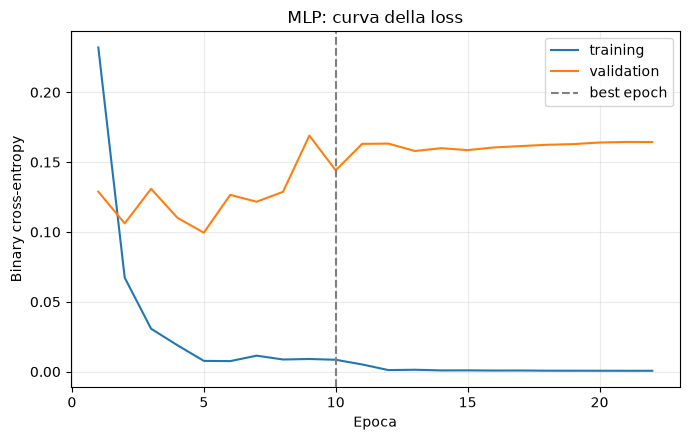

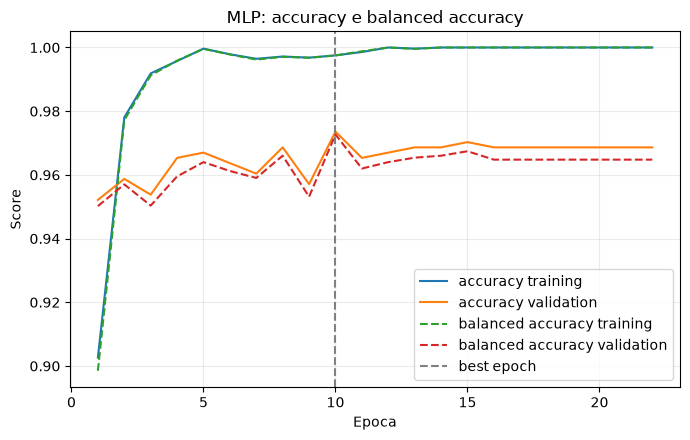

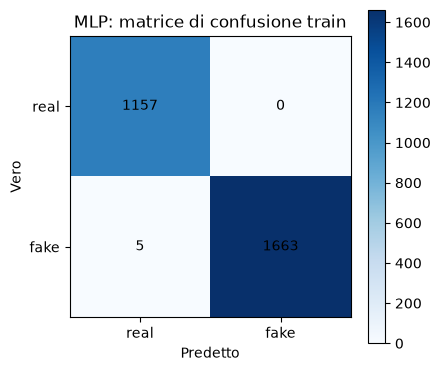

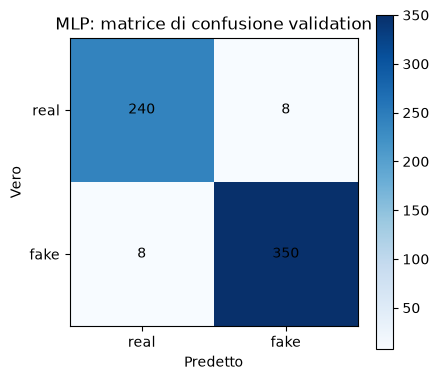

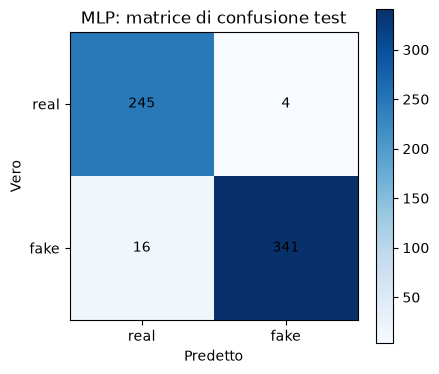

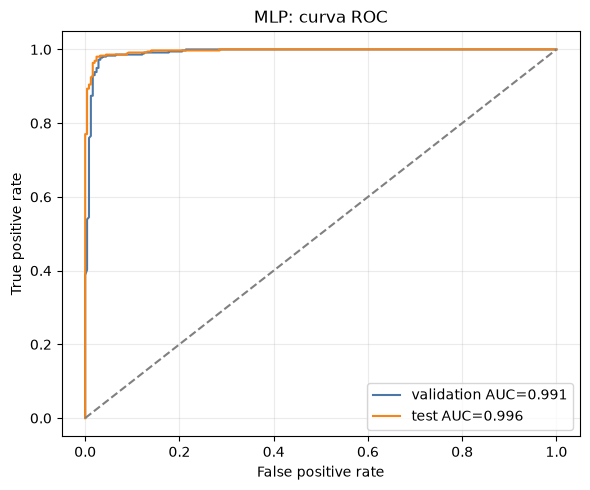

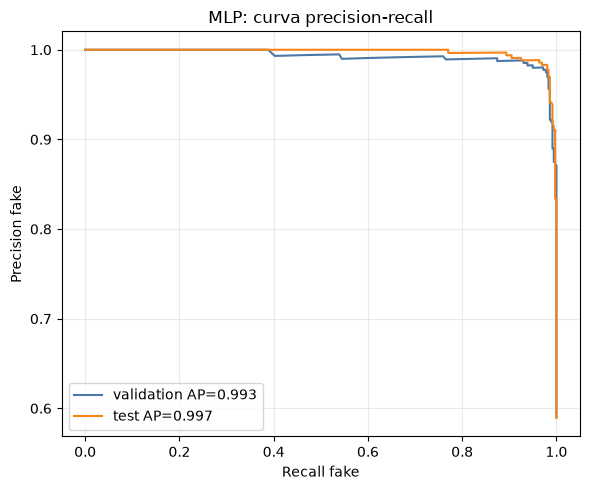

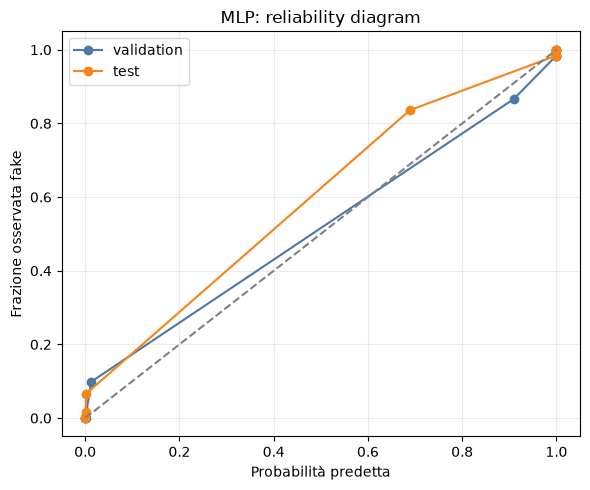

In [8]:
def save_figure(filename):
    plt.tight_layout()
    plt.savefig(primary_experiment['figures_dir'] / filename, dpi=200, bbox_inches='tight')
    plt.show()
    plt.close()

history = primary_experiment['history']
plt.figure(figsize=(7, 4.5))
plt.plot(history['step'], history['train_loss'], label='training')
plt.plot(history['step'], history['val_loss'], label='validation')
plt.axvline(primary_experiment['best_epoch'], color='grey', linestyle='--', label='best epoch')
plt.xlabel('Epoca')
plt.ylabel('Binary cross-entropy')
plt.title('MLP: curva della loss')
plt.legend()
plt.grid(alpha=0.25)
save_figure('loss_curve.png')

plt.figure(figsize=(7, 4.5))
plt.plot(history['step'], history['train_accuracy'], label='accuracy training')
plt.plot(history['step'], history['val_accuracy'], label='accuracy validation')
plt.plot(history['step'], history['train_balanced_accuracy'], linestyle='--', label='balanced accuracy training')
plt.plot(history['step'], history['val_balanced_accuracy'], linestyle='--', label='balanced accuracy validation')
plt.axvline(primary_experiment['best_epoch'], color='grey', linestyle='--', label='best epoch')
plt.xlabel('Epoca')
plt.ylabel('Score')
plt.title('MLP: accuracy e balanced accuracy')
plt.legend()
plt.grid(alpha=0.25)
save_figure('accuracy_curve.png')

for split_name in ('train', 'validation', 'test'):
    matrix = evaluations[split_name][2]
    plt.figure(figsize=(4.5, 4))
    image = plt.imshow(matrix, cmap='Blues')
    plt.colorbar(image)
    plt.xticks([0, 1], ['real', 'fake'])
    plt.yticks([0, 1], ['real', 'fake'])
    plt.xlabel('Predetto')
    plt.ylabel('Vero')
    plt.title(f'MLP: matrice di confusione {split_name}')
    for row in range(2):
        for column in range(2):
            plt.text(column, row, str(matrix[row, column]), ha='center', va='center')
    save_figure(f'confusion_matrix_{split_name}.png')

plt.figure(figsize=(6, 5))
for split_name, color in (('validation', '#4c78a8'), ('test', '#f58518')):
    y_current = primary_experiment['y_validation'] if split_name == 'validation' else primary_experiment['y_test']
    probabilities = evaluations[split_name][3]
    fpr, tpr, _ = roc_curve(y_current, probabilities, pos_label=POSITIVE_LABEL)
    plt.plot(fpr, tpr, color=color, label=f'{split_name} AUC={roc_auc_score(y_current, probabilities):.3f}')
plt.plot([0, 1], [0, 1], '--', color='grey')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('MLP: curva ROC')
plt.legend(loc='lower right')
plt.grid(alpha=0.25)
save_figure('roc_curve.png')

plt.figure(figsize=(6, 5))
for split_name, color in (('validation', '#4c78a8'), ('test', '#f58518')):
    y_current = primary_experiment['y_validation'] if split_name == 'validation' else primary_experiment['y_test']
    probabilities = evaluations[split_name][3]
    precision, recall, _ = precision_recall_curve(y_current, probabilities, pos_label=POSITIVE_LABEL)
    plt.plot(recall, precision, color=color, label=f'{split_name} AP={average_precision_score(y_current, probabilities):.3f}')
plt.xlabel('Recall fake')
plt.ylabel('Precision fake')
plt.title('MLP: curva precision-recall')
plt.legend()
plt.grid(alpha=0.25)
save_figure('precision_recall_curve.png')

plt.figure(figsize=(6, 5))
for split_name, color in (('validation', '#4c78a8'), ('test', '#f58518')):
    y_current = primary_experiment['y_validation'] if split_name == 'validation' else primary_experiment['y_test']
    probabilities = evaluations[split_name][3]
    observed, predicted = calibration_curve(y_current, probabilities, n_bins=10, strategy='quantile')
    plt.plot(predicted, observed, marker='o', color=color, label=split_name)
plt.plot([0, 1], [0, 1], '--', color='grey')
plt.xlabel('Probabilità predetta')
plt.ylabel('Frazione osservata fake')
plt.title('MLP: reliability diagram')
plt.legend()
plt.grid(alpha=0.25)
save_figure('calibration_curve.png')

## 9. Verifica del modello ricaricato e riepilogo riproducibile

La cella ricarica scaler, state dict e modello TorchScript dal disco, verifica la coincidenza delle probabilità validation entro tolleranza e salva un riepilogo JSON con configurazione, hash dello split, metriche e percorsi degli artefatti.

In [9]:
reloaded_scaler = joblib.load(primary_experiment['run_dir'] / 'scaler.joblib')
reloaded_model = TabularMLP(
    primary_experiment['model_config']['input_dimension'],
    tuple(primary_experiment['model_config']['hidden_dimensions']),
    primary_experiment['model_config']['dropout'],
).to(DEVICE)
reloaded_state_dict = torch.load(primary_experiment['state_path'], map_location=DEVICE, weights_only=True)
reloaded_model.load_state_dict(reloaded_state_dict)
reloaded_validation_inputs = reloaded_scaler.transform(np.asarray(FEATURE_SETS[PRIMARY_REPRESENTATION][validation_indices], dtype=np.float32)).astype(np.float32, copy=False)
reloaded_logits = predict_logits(reloaded_model, reloaded_validation_inputs)
original_logits = predict_logits(primary_experiment['model'], primary_experiment['X_validation'])
if not np.allclose(reloaded_logits, original_logits, rtol=1e-5, atol=1e-6):
    raise RuntimeError('Le predizioni del modello ricaricato non coincidono con quelle originali')
if primary_experiment['scripted_path'] is not None:
    scripted_model = torch.jit.load(str(primary_experiment['scripted_path']), map_location=DEVICE).eval()
    scripted_logits = predict_logits(scripted_model, primary_experiment['X_validation'])
    if not np.allclose(scripted_logits, original_logits, rtol=1e-5, atol=1e-6):
        raise RuntimeError('Le predizioni TorchScript non coincidono con quelle del modello PyTorch')
else:
    print(f'TorchScript non verificabile: {primary_experiment["torchscript_error"]}')

ablation_summary = {
    name: {'run_id': experiment['run_id'], 'best_epoch': experiment['best_epoch'], 'validation_balanced_accuracy': experiment['best_validation_score']}
    for name, experiment in experiments.items()
}
summary = {
    'run_id': primary_experiment['run_id'], 'model': MODEL_NAME, 'representation': PRIMARY_REPRESENTATION,
    'decision_threshold': decision_threshold, 'threshold_selection_split': 'validation',
    'split_hash': SPLIT_HASH, 'split_summary': SPLIT_SUMMARY, 'versions': VERSIONS,
    'ablation_runs': ablation_summary, 'metrics': metrics_frame.to_dict(orient='records'),
    'artifacts': {
        'best_state_dict': str(primary_experiment['state_path']),
        'model_config': str(primary_experiment['run_dir'] / 'model_config.json'),
        'scaler': str(primary_experiment['run_dir'] / 'scaler.joblib'),
        'torchscript': None if primary_experiment['scripted_path'] is None else str(primary_experiment['scripted_path']),
        'torchscript_error': primary_experiment['torchscript_error'],
        'history': str(primary_experiment['run_dir'] / 'history.csv'),
        'metrics': str(primary_experiment['run_dir'] / 'metrics.csv'),
        'predictions': str(primary_experiment['run_dir'] / 'predictions.csv'),
        'figures': str(primary_experiment['figures_dir']),
    },
}
atomic_json(summary, primary_experiment['run_dir'] / 'summary.json')
print('Ricaricamento state dict verificato; TorchScript verificato quando disponibile.')
display(metrics_frame[['split', 'balanced_accuracy', 'roc_auc', 'pr_auc', 'f1', 'threshold']])

c:\Users\leona\venv_aml\.venv\Lib\site-packages\torch\jit\_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(


Ricaricamento state dict verificato; TorchScript verificato quando disponibile.


,split,balanced_accuracy,roc_auc,pr_auc,f1,threshold
0,train,0.998501,0.999997,0.999998,0.998499,0.5
1,validation,0.972698,0.991367,0.992748,0.977654,0.5
2,test,0.969559,0.995900,0.997174,0.971510,0.5


## Output e artefatti prodotti

Per l'esperimento primario, la directory `results/mlp/<run_id>/` contiene:

- `best_state_dict.pt`: pesi del miglior checkpoint, selezionato su validation;
- `model_config.json` e `scaler.joblib`: architettura, metadati e preprocessing necessario all'inferenza;
- `best_model_scripted.pt`: esportazione TorchScript del modello, quando supportata dall'ambiente;
- `history.csv`, `metrics.csv` e `predictions.csv`: andamento per epoca, metriche per split e predizioni allineate tramite `sample_id`;
- `figures/`: loss, accuracy, matrici di confusione, ROC, precision-recall e reliability diagram;
- `summary.json`: hash dello split, soglia selezionata su validation, versioni e indice degli artefatti.

Se `RUN_GAP_ABLATION=True`, viene creata una seconda directory di run con la stessa struttura per il confronto GAP. Il test set non è usato per selezionare architettura, epoca, soglia o iperparametri. I risultati vanno interpretati considerando i possibili bias o confondenti del dataset già discussi nel piano di progetto.